Replicating results of research:
https://link.springer.com/article/10.1007/s10479-024-06134-x

Made by-  
Anirudh  
Shreyas  
Tashya  
Varun

In [1]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, auc

Data & EDA

Dataset Shape: (30000, 24)
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...          0          0          0         0       689         0   
1      0  ...       3272       3455       3261         0      1000      1000   
2      0  ...      14331      14948      15549      1518      1500      1000   
3      0  ...      28314      28959      29547      2000      2019      1200   
4      0  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default 

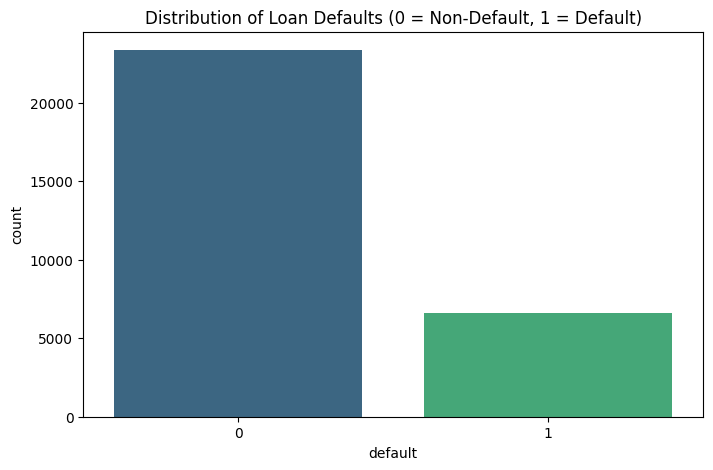

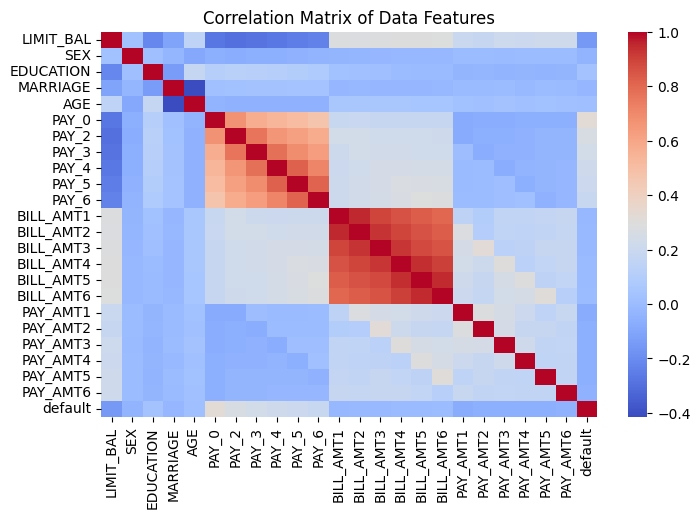

In [4]:
path = "default of credit card clients.xls"
df = pd.read_excel(path, header=1)
df = df.rename(columns={'default payment next month': 'default'})
df = df.drop(columns=['ID'])
print(f"Dataset Shape: {df.shape}")
print(df.head())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='default', hue='default', palette='viridis', legend=False)
plt.title('Distribution of Loan Defaults (0 = Non-Default, 1 = Default)')
plt.show()

plt.figure(figsize=(8, 5))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Matrix of Data Features')
plt.show()

Models + evaluation function

In [5]:
X = df.drop(columns=['default'])
y = df['default']
feature_names = X.columns.tolist()

def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "KNN": KNeighborsClassifier(),
        "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
        "Naive Bayes": GaussianNB(),
        "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1),
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "LDA": LinearDiscriminantAnalysis(),
        "MLP": MLPClassifier(max_iter=500, random_state=42),
        "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
        "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
        "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
        "QDA": QuadraticDiscriminantAnalysis(),
        "SVM": SVC(probability=True, random_state=42)
    }

def evaluate_models(X_train, X_test, y_train, y_test):
    results = []
    trained = {}
    for name, model in get_models().items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        trained[name] = model
        y_pred = model.predict(X_test)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = model.decision_function(X_test)
            y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
        results.append({
            "Algorithm": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "PR-AUC": auc(recall_vals, precision_vals)
        })
    return pd.DataFrame(results).round(4), trained

Pipeline 1 — Without fix (leakage)

In [6]:
scaler_flawed = StandardScaler()
X_scaled_flawed = scaler_flawed.fit_transform(X)

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_scaled_flawed, y)
X_res = pd.DataFrame(X_res, columns=feature_names)

X_train_flawed, X_test_flawed, y_train_flawed, y_test_flawed = train_test_split(
    X_res, y_res, test_size=0.25, random_state=42, stratify=y_res
)

print(y_train_flawed.value_counts())
print(y_test_flawed.value_counts())

results_flawed_df, trained_flawed = evaluate_models(X_train_flawed, X_test_flawed, y_train_flawed, y_test_flawed)
results_flawed_df = results_flawed_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
print("Without Fix (Leakage)")
display(results_flawed_df)

default
0    17523
1    17523
Name: count, dtype: int64
default
1    5841
0    5841
Name: count, dtype: int64
Training Logistic Regression...
Training Decision Tree...
Training KNN...
Training Random Forest...
Training Naive Bayes...
Training LightGBM...
Training AdaBoost...
Training Gradient Boosting...
Training LDA...
Training MLP...
Training XGBoost...
Training CatBoost...
Training Extra Trees...
Training QDA...
Training SVM...
Without Fix (Leakage)


,Algorithm,Accuracy,Precision,Recall,F1 Score,PR-AUC
0,Extra Trees,0.9355,0.9216,0.9521,0.9366,0.9856
1,Random Forest,0.9274,0.9047,0.9555,0.9294,0.9801
2,Decision Tree,0.8669,0.8133,0.9524,0.8774,0.8945
3,XGBoost,0.8047,0.7977,0.8163,0.8069,0.8680
4,CatBoost,0.7806,0.7982,0.7511,0.7739,0.8508
5,KNN,0.7458,0.7116,0.8267,0.7649,0.8241
6,LightGBM,0.7494,0.7692,0.7127,0.7399,0.8283
7,MLP,0.7312,0.7444,0.7042,0.7237,0.7927
8,Gradient Boosting,0.7225,0.7592,0.6516,0.7013,0.7976
9,Naive Bayes,0.6370,0.6063,0.7817,0.6829,0.7507


Pipeline 2 — With fix (corrected)

In [7]:
X_train_raw, X_test_raw, y_train_raw, y_test_fixed = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler_fixed = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_fixed.fit_transform(X_train_raw), columns=feature_names)
X_test_fixed = pd.DataFrame(scaler_fixed.transform(X_test_raw), columns=feature_names)

ros_fixed = RandomOverSampler(random_state=42)
X_train_fixed, y_train_fixed = ros_fixed.fit_resample(X_train_scaled, y_train_raw)

print(y_train_fixed.value_counts())
print(y_test_fixed.value_counts())

results_fixed_df, trained_fixed = evaluate_models(X_train_fixed, X_test_fixed, y_train_fixed, y_test_fixed)
results_fixed_df = results_fixed_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
print("With Fix (Corrected)")
display(results_fixed_df)

default
1    17523
0    17523
Name: count, dtype: int64
default
0    5841
1    1659
Name: count, dtype: int64
Training Logistic Regression...
Training Decision Tree...
Training KNN...
Training Random Forest...
Training Naive Bayes...
Training LightGBM...
Training AdaBoost...
Training Gradient Boosting...
Training LDA...
Training MLP...
Training XGBoost...
Training CatBoost...
Training Extra Trees...
Training QDA...
Training SVM...
With Fix (Corrected)


,Algorithm,Accuracy,Precision,Recall,F1 Score,PR-AUC
0,Gradient Boosting,0.7604,0.4687,0.6221,0.5346,0.5577
1,LightGBM,0.7587,0.4658,0.6190,0.5316,0.5568
2,CatBoost,0.7668,0.4780,0.5895,0.5279,0.5492
3,AdaBoost,0.7633,0.4722,0.5943,0.5263,0.5323
4,SVM,0.7709,0.4849,0.5702,0.5241,0.4880
5,XGBoost,0.7636,0.4717,0.5732,0.5176,0.5233
6,Random Forest,0.8083,0.5914,0.4310,0.4986,0.5280
7,MLP,0.7151,0.4018,0.5895,0.4779,0.4699
8,Logistic Regression,0.6749,0.3658,0.6401,0.4656,0.4991
9,LDA,0.6785,0.3673,0.6275,0.4634,0.4973


Comparison

,Algorithm,F1 Score (No Fix),F1 Score (Fixed),F1 Inflation,Accuracy (No Fix),Accuracy (Fixed),PR-AUC (No Fix),PR-AUC (Fixed)
0,Decision Tree,0.8774,0.3891,0.4883,0.8669,0.7308,0.8945,0.4567
1,Extra Trees,0.9366,0.4621,0.4745,0.9355,0.8119,0.9856,0.5209
2,Random Forest,0.9294,0.4986,0.4308,0.9274,0.8083,0.9801,0.5280
3,KNN,0.7649,0.4390,0.3259,0.7458,0.6552,0.8241,0.4399
4,XGBoost,0.8069,0.5176,0.2893,0.8047,0.7636,0.8680,0.5233
5,QDA,0.6774,0.3970,0.2804,0.5812,0.4053,0.7143,0.4312
6,Naive Bayes,0.6829,0.4264,0.2565,0.6370,0.5236,0.7507,0.4927
7,CatBoost,0.7739,0.5279,0.2460,0.7806,0.7668,0.8508,0.5492
8,MLP,0.7237,0.4779,0.2458,0.7312,0.7151,0.7927,0.4699
9,LightGBM,0.7399,0.5316,0.2083,0.7494,0.7587,0.8283,0.5568


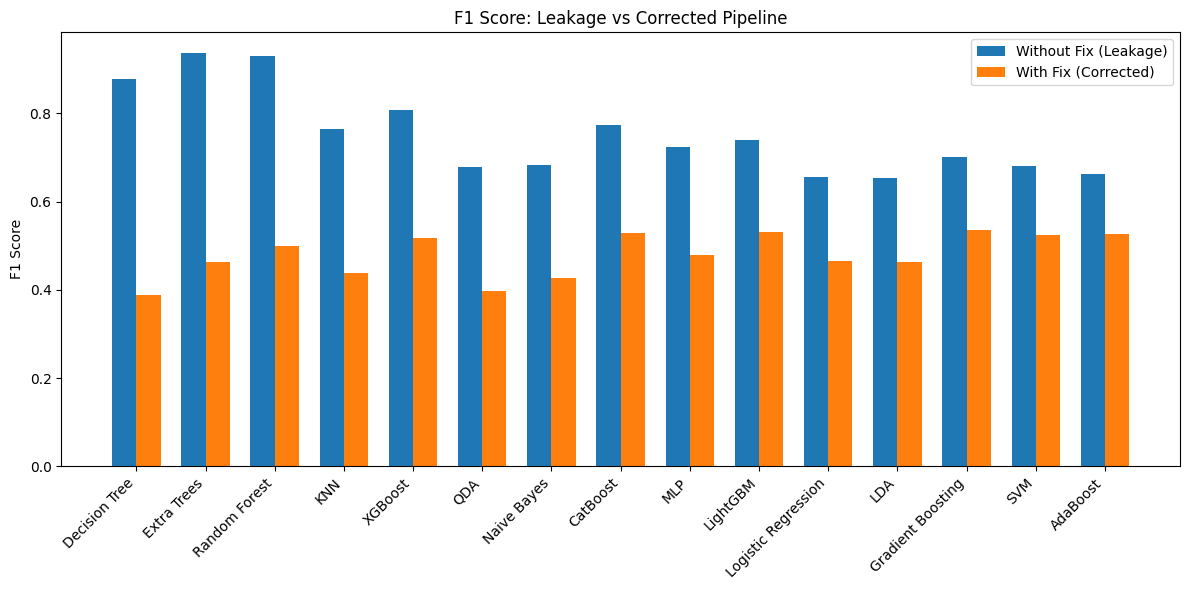

In [8]:
comparison_df = results_flawed_df.merge(results_fixed_df, on="Algorithm", suffixes=(" (No Fix)", " (Fixed)"))
comparison_df["F1 Inflation"] = comparison_df["F1 Score (No Fix)"] - comparison_df["F1 Score (Fixed)"]
comparison_df = comparison_df.sort_values(by="F1 Inflation", ascending=False).reset_index(drop=True)

display(comparison_df[["Algorithm", "F1 Score (No Fix)", "F1 Score (Fixed)", "F1 Inflation",
                        "Accuracy (No Fix)", "Accuracy (Fixed)",
                        "PR-AUC (No Fix)", "PR-AUC (Fixed)"]])

x = np.arange(len(comparison_df))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, comparison_df["F1 Score (No Fix)"], width, label="Without Fix (Leakage)")
plt.bar(x + width/2, comparison_df["F1 Score (Fixed)"], width, label="With Fix (Corrected)")
plt.xticks(x, comparison_df["Algorithm"], rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("F1 Score: Leakage vs Corrected Pipeline")
plt.legend()
plt.tight_layout()
plt.show()

Save corrected models

In [9]:
os.makedirs("pickle_models", exist_ok=True)
for name, model in trained_fixed.items():
    filename = name.replace(" ", "_").lower()
    filepath = f"pickle_models/{filename}.pkl"
    with open(filepath, 'wb') as file:
        pickle.dump(model, file)
    print(f"Saved: {filepath}")

Saved: pickle_models/logistic_regression.pkl
Saved: pickle_models/decision_tree.pkl
Saved: pickle_models/knn.pkl
Saved: pickle_models/random_forest.pkl
Saved: pickle_models/naive_bayes.pkl
Saved: pickle_models/lightgbm.pkl
Saved: pickle_models/adaboost.pkl
Saved: pickle_models/gradient_boosting.pkl
Saved: pickle_models/lda.pkl
Saved: pickle_models/mlp.pkl
Saved: pickle_models/xgboost.pkl
Saved: pickle_models/catboost.pkl
Saved: pickle_models/extra_trees.pkl
Saved: pickle_models/qda.pkl
Saved: pickle_models/svm.pkl


Threshold optimization

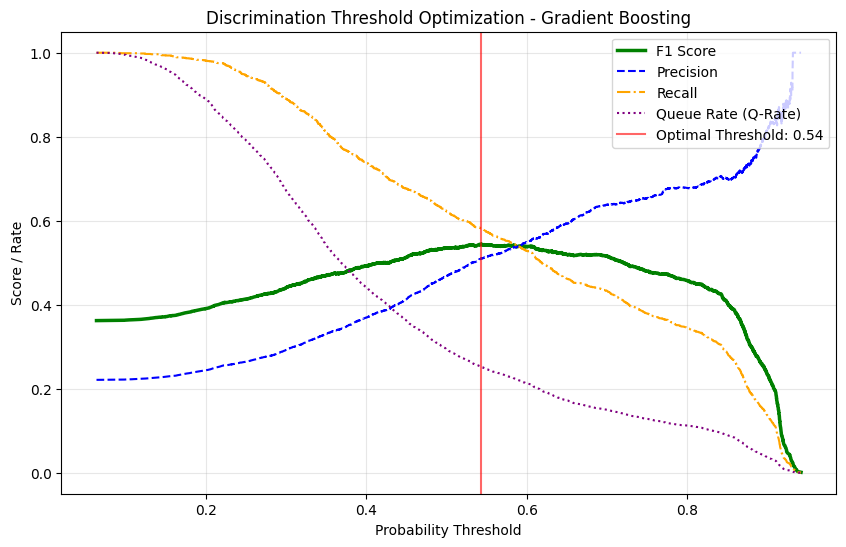

Optimal Threshold for Gradient Boosting: 0.5433
  -> Max F1 Score: 0.5440
  -> Queue Rate:   0.2519 (25.2% of applications will be flagged)


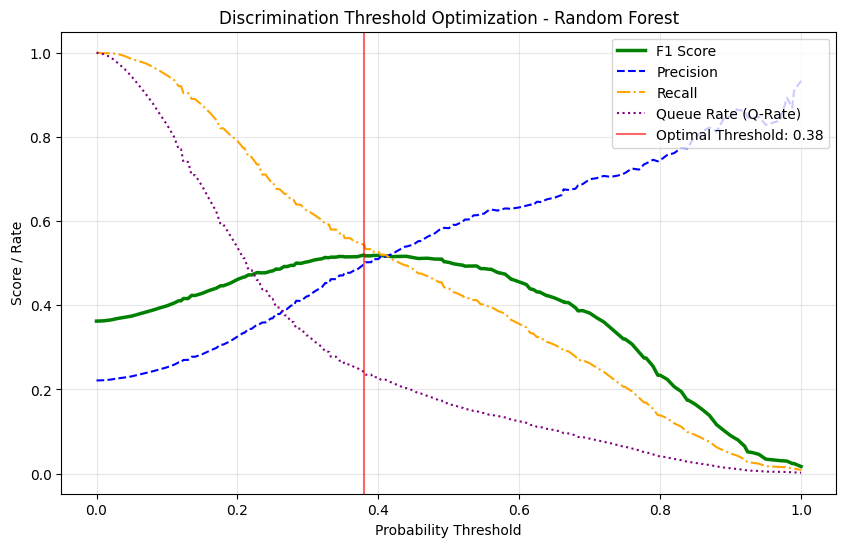

Optimal Threshold for Random Forest: 0.3800
  -> Max F1 Score: 0.5191
  -> Queue Rate:   0.2427 (24.3% of applications will be flagged)


In [10]:
def optimize_threshold(model, name, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    q_rates = [np.mean(y_proba >= t) for t in thresholds]
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    max_f1 = f1_scores[optimal_idx]
    optimal_q_rate = q_rates[optimal_idx]

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, label='F1 Score', color='green', linewidth=2.5)
    plt.plot(thresholds, precisions[:-1], label='Precision', color='blue', linestyle='--')
    plt.plot(thresholds, recalls[:-1], label='Recall', color='orange', linestyle='-.')
    plt.plot(thresholds, q_rates, label='Queue Rate (Q-Rate)', color='purple', linestyle=':')
    plt.axvline(x=optimal_threshold, color='red', linestyle='-', alpha=0.6, label=f'Optimal Threshold: {optimal_threshold:.2f}')
    plt.title(f'Discrimination Threshold Optimization - {name}')
    plt.xlabel('Probability Threshold')
    plt.ylabel('Score / Rate')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.show()

    print(f"Optimal Threshold for {name}: {optimal_threshold:.4f}")
    print(f"  -> Max F1 Score: {max_f1:.4f}")
    print(f"  -> Queue Rate:   {optimal_q_rate:.4f} ({optimal_q_rate*100:.1f}% of applications will be flagged)")
    return optimal_threshold

gb_model = trained_fixed["Gradient Boosting"]
rf_model = trained_fixed["Random Forest"]

gb_thresh = optimize_threshold(gb_model, "Gradient Boosting", X_test_fixed, y_test_fixed)
rf_thresh = optimize_threshold(rf_model, "Random Forest", X_test_fixed, y_test_fixed)

Feature importance

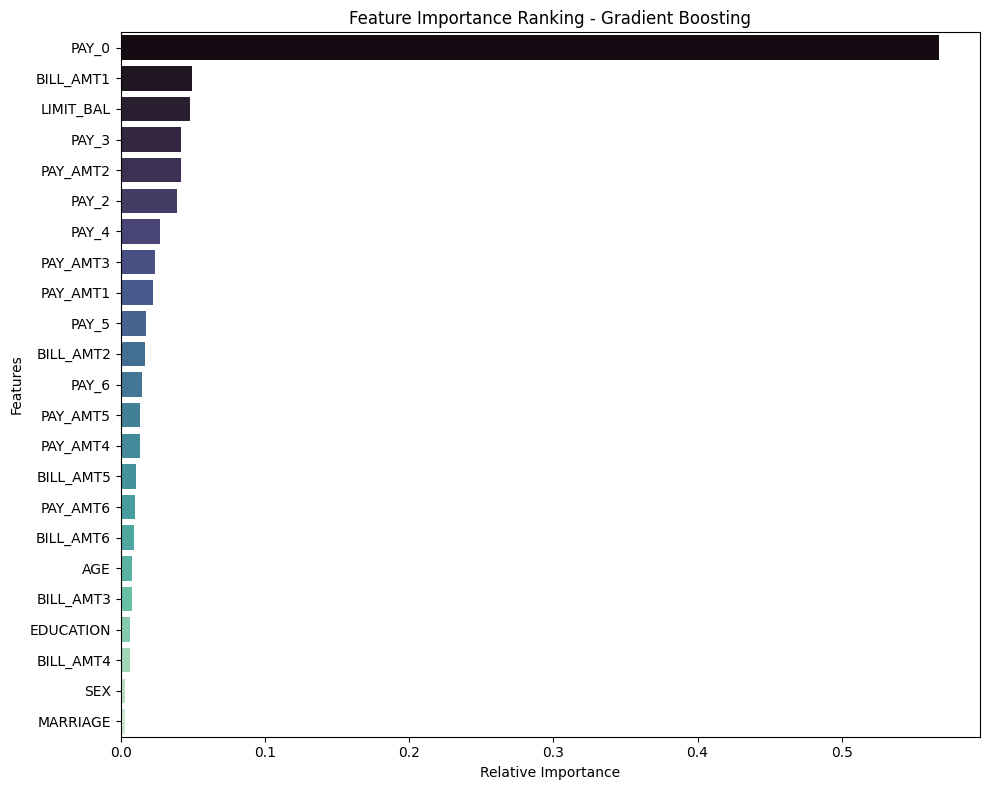

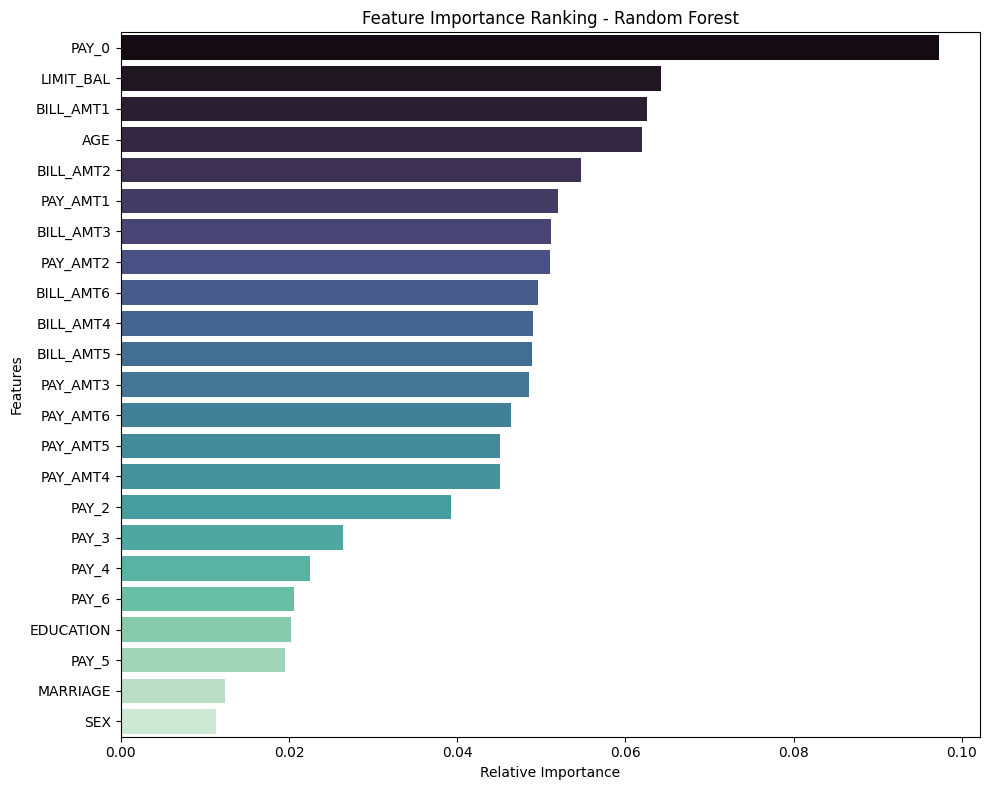

In [11]:
def plot_feature_importance(model, name, feature_names):
    importances = model.feature_importances_
    df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    df_importance = df_importance.sort_values(by='Importance', ascending=False)
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=df_importance, hue='Feature', palette='mako', legend=False)
    plt.title(f'Feature Importance Ranking - {name}')
    plt.xlabel('Relative Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

plot_feature_importance(gb_model, "Gradient Boosting", feature_names)
plot_feature_importance(rf_model, "Random Forest", feature_names)

SHAP

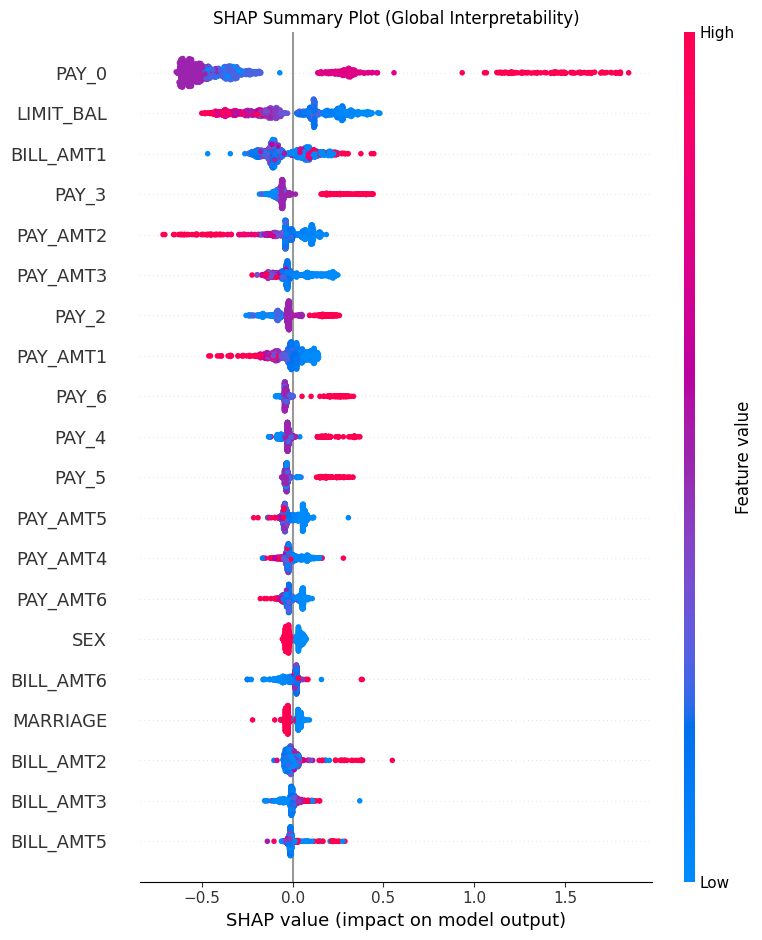

Local Explanation for Borrower #0:


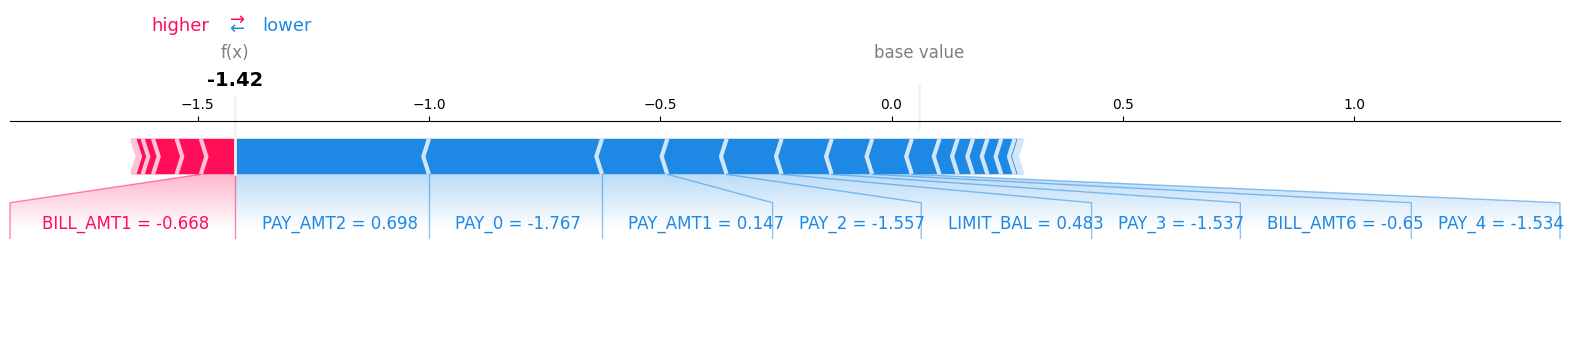

In [12]:
X_test_sample = shap.sample(X_test_fixed, 1000)
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot (Global Interpretability)")
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.show()

shap.initjs()
print("Local Explanation for Borrower #0:")
shap.force_plot(
    explainer.expected_value,
    shap_values[0,:],
    X_test_sample.iloc[0,:].round(3),
    matplotlib=True
)